In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
df = pd.read_csv('datafile.csv')
df

,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%),Unnamed: 136
0,India,Urban,160138,179535,26420,82.5,23.1,985.0,924,93.3,...,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5,NaN
1,India,Rural,476561,544580,75419,66.8,28.1,1037.0,931,87.5,...,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9,NaN
2,India,Total,636699,724115,101839,71.8,26.5,1020.0,929,89.1,...,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8,NaN
3,Andaman & Nicobar Islands,Urban,527,557,85,86.5,22.7,1023.0,941,96.9,...,80.8,98.5,23.2,(0.0),1.4,15.0,44.7,0.7,33.8,NaN
4,Andaman & Nicobar Islands,Rural,2097,1840,282,81.8,19.7,929.0,891,97.8,...,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358,2586,316,82.4,24.7,943.0,1094,92.2,...,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7,NaN
106,Uttarakhand,Rural,9811,10694,1270,72.0,27.1,1052.0,937,91.8,...,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5,NaN
107,Uttarakhand,Total,12169,13280,1586,75.2,26.3,1016.0,984,91.9,...,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5,NaN
108,West Bengal,Urban,5442,6358,942,84.1,20.2,1016.0,921,98.1,...,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9,NaN


In [17]:
df = pd.read_csv('datafile.csv')


df = df.dropna(how='all')             
df = df.dropna(axis=1, how='all')     


def clean_nfhs_values(val):
    if pd.isna(val) or str(val).strip() == "":
        return np.nan
    val_str = str(val).strip()

    if "(" in val_str:
        val_str = val_str.replace("(", "").replace(")", "")
    try:
        # Convert to number
        return float(val_str)
    except ValueError:
        # Keep as text if it's a name (like state names)
        return val_str

# 4. Apply cleaning to all indicator columns
# We skip 'States/UTs' and 'Area' to keep them as labels
labels = ['States/UTs', 'Area']
cols_to_clean = [c for c in df.columns if c not in labels]

for col in cols_to_clean:
    df[col] = df[col].apply(clean_nfhs_values)

# 5. Save the final cleaned file
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned file saved as 'cleaned_data.csv'")
df

Cleaned file saved as 'cleaned_data.csv'


,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a bank or savings account that they themselves use (%),Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,India,Urban,160138.0,179535.0,26420.0,82.5,23.1,985.0,924.0,93.3,...,80.9,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5
1,India,Rural,476561.0,544580.0,75419.0,66.8,28.1,1037.0,931.0,87.5,...,77.4,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9
2,India,Total,636699.0,724115.0,101839.0,71.8,26.5,1020.0,929.0,89.1,...,78.6,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8
3,Andaman & Nicobar Islands,Urban,527.0,557.0,85.0,86.5,22.7,1023.0,941.0,96.9,...,88.5,80.8,98.5,23.2,0.0,1.4,15.0,44.7,0.7,33.8
4,Andaman & Nicobar Islands,Rural,2097.0,1840.0,282.0,81.8,19.7,929.0,891.0,97.8,...,89.8,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358.0,2586.0,316.0,82.4,24.7,943.0,1094.0,92.2,...,81.3,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7
106,Uttarakhand,Rural,9811.0,10694.0,1270.0,72.0,27.1,1052.0,937.0,91.8,...,79.8,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5
107,Uttarakhand,Total,12169.0,13280.0,1586.0,75.2,26.3,1016.0,984.0,91.9,...,80.2,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5
108,West Bengal,Urban,5442.0,6358.0,942.0,84.1,20.2,1016.0,921.0,98.1,...,82.9,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9


In [18]:
d2 = pd.read_csv('cleaned_data.csv')
d2

,States/UTs,Area,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Women (age 15-49 years) having a bank or savings account that they themselves use (%),Women (age 15-49 years) having a mobile phone that they themselves use (%),Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%),Ever-married women age 18-49 years who have ever experienced spousal violence27 (%),Ever-married women age 18-49 years who have experienced physical violence during any pregnancy (%),Young women age 18-29 years who experienced sexual violence by age 18 (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,India,Urban,160138.0,179535.0,26420.0,82.5,23.1,985.0,924.0,93.3,...,80.9,69.4,89.4,24.2,2.5,1.1,5.4,28.8,0.6,16.5
1,India,Rural,476561.0,544580.0,75419.0,66.8,28.1,1037.0,931.0,87.5,...,77.4,46.6,72.3,31.6,3.4,1.6,10.5,42.7,1.6,19.9
2,India,Total,636699.0,724115.0,101839.0,71.8,26.5,1020.0,929.0,89.1,...,78.6,54.0,77.3,29.3,3.1,1.5,8.9,38.0,1.3,18.8
3,Andaman & Nicobar Islands,Urban,527.0,557.0,85.0,86.5,22.7,1023.0,941.0,96.9,...,88.5,80.8,98.5,23.2,0.0,1.4,15.0,44.7,0.7,33.8
4,Andaman & Nicobar Islands,Rural,2097.0,1840.0,282.0,81.8,19.7,929.0,891.0,97.8,...,89.8,80.9,99.1,13.2,0.5,2.2,41.1,66.4,7.6,41.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Uttarakhand,Urban,2358.0,2586.0,316.0,82.4,24.7,943.0,1094.0,92.2,...,81.3,73.1,94.5,12.5,2.4,0.0,2.8,27.6,0.3,21.7
106,Uttarakhand,Rural,9811.0,10694.0,1270.0,72.0,27.1,1052.0,937.0,91.8,...,79.8,55.7,89.7,16.2,2.0,0.4,5.4,36.8,0.4,27.5
107,Uttarakhand,Total,12169.0,13280.0,1586.0,75.2,26.3,1016.0,984.0,91.9,...,80.2,60.9,91.2,15.1,2.1,0.3,4.6,33.7,0.3,25.5
108,West Bengal,Urban,5442.0,6358.0,942.0,84.1,20.2,1016.0,921.0,98.1,...,82.9,71.9,91.2,22.9,2.3,6.7,8.0,44.7,0.8,18.9


In [19]:
df = pd.read_csv('datafile.csv')

def clean_data(val):
    if pd.isna(val) or val == "" or val == " ":
        return np.nan
    val = str(val).strip().replace("(", "").replace(")", "")
    try:
        return float(val)
    except ValueError:
        return np.nan

cols = [
    'Women (age 15-49) who are literate4 (%)',
    'Total Fertility Rate (number of children per woman)',
    'Women (age 15-49)  who have ever used the internet (%)',
    'Households using clean fuel for cooking3 (%)',
    'Population living in households that use an improved sanitation facility2 (%)'
]

for col in cols:
    df[col] = df[col].apply(clean_data)

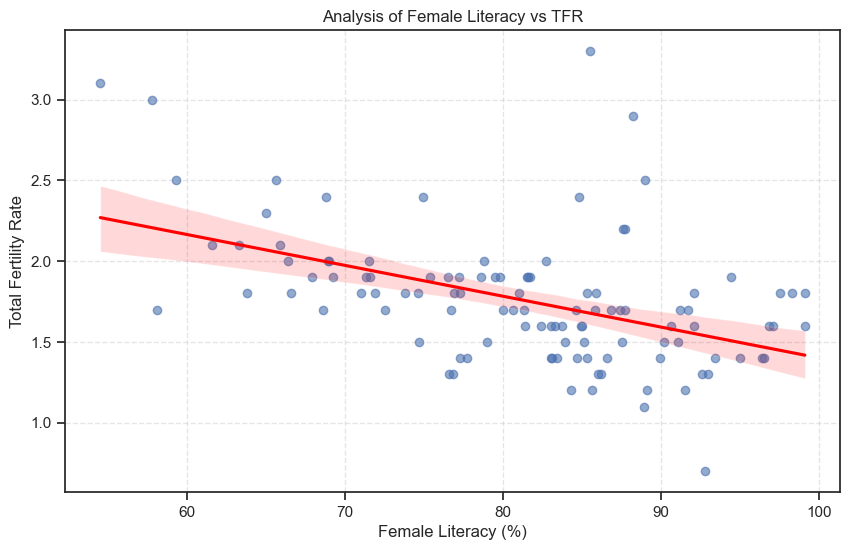

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x=cols[0], y=cols[1], 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Analysis of Female Literacy vs TFR')
plt.xlabel('Female Literacy (%)')
plt.ylabel('Total Fertility Rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('literacy_vs_tfr.png', dpi=300)
plt.show()

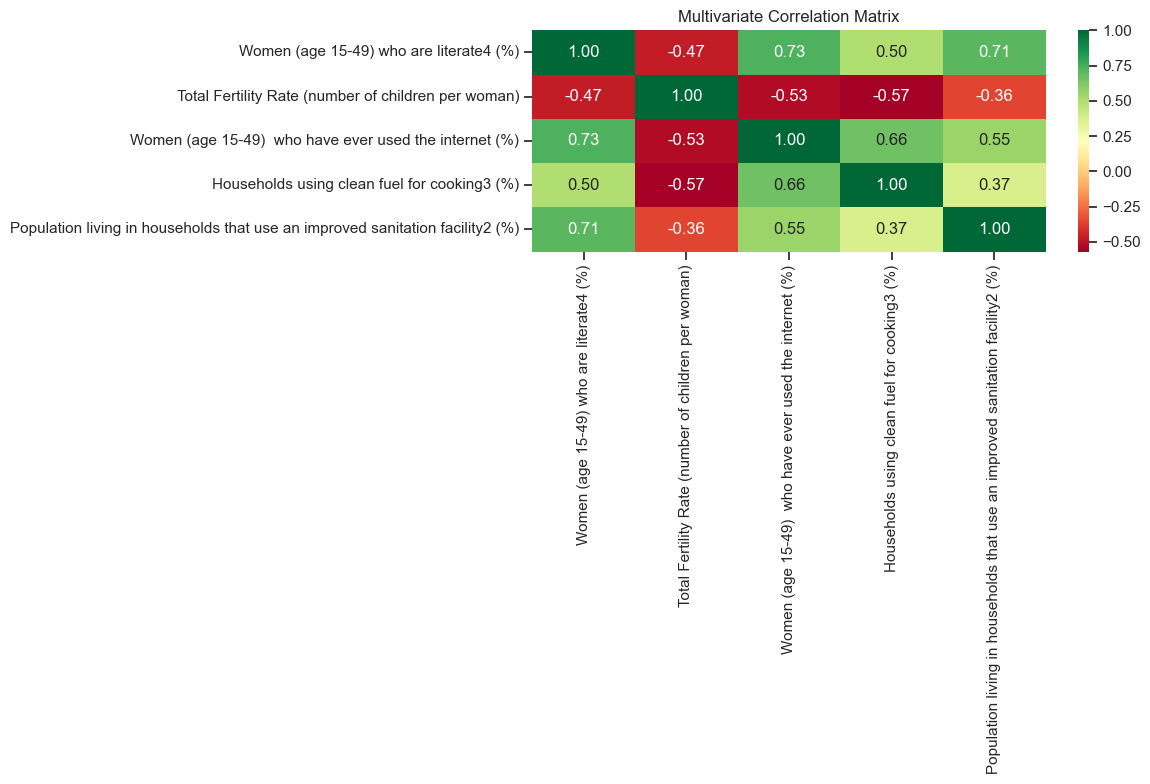

In [21]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Multivariate Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

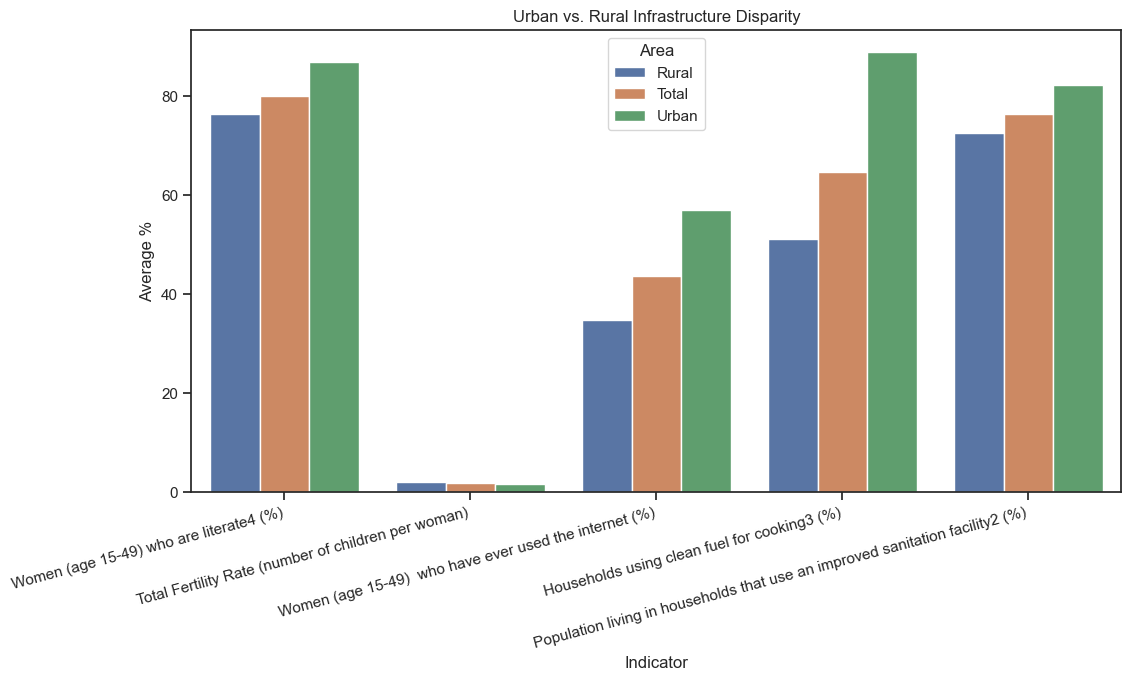

In [22]:

area_stats = df.groupby('Area')[cols].mean().reset_index()
melted_df = area_stats.melt(id_vars='Area', var_name='Indicator', value_name='Average %')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Indicator', y='Average %', hue='Area')
plt.xticks(rotation=15, ha='right')
plt.title('Urban vs. Rural Infrastructure Disparity')
plt.show()

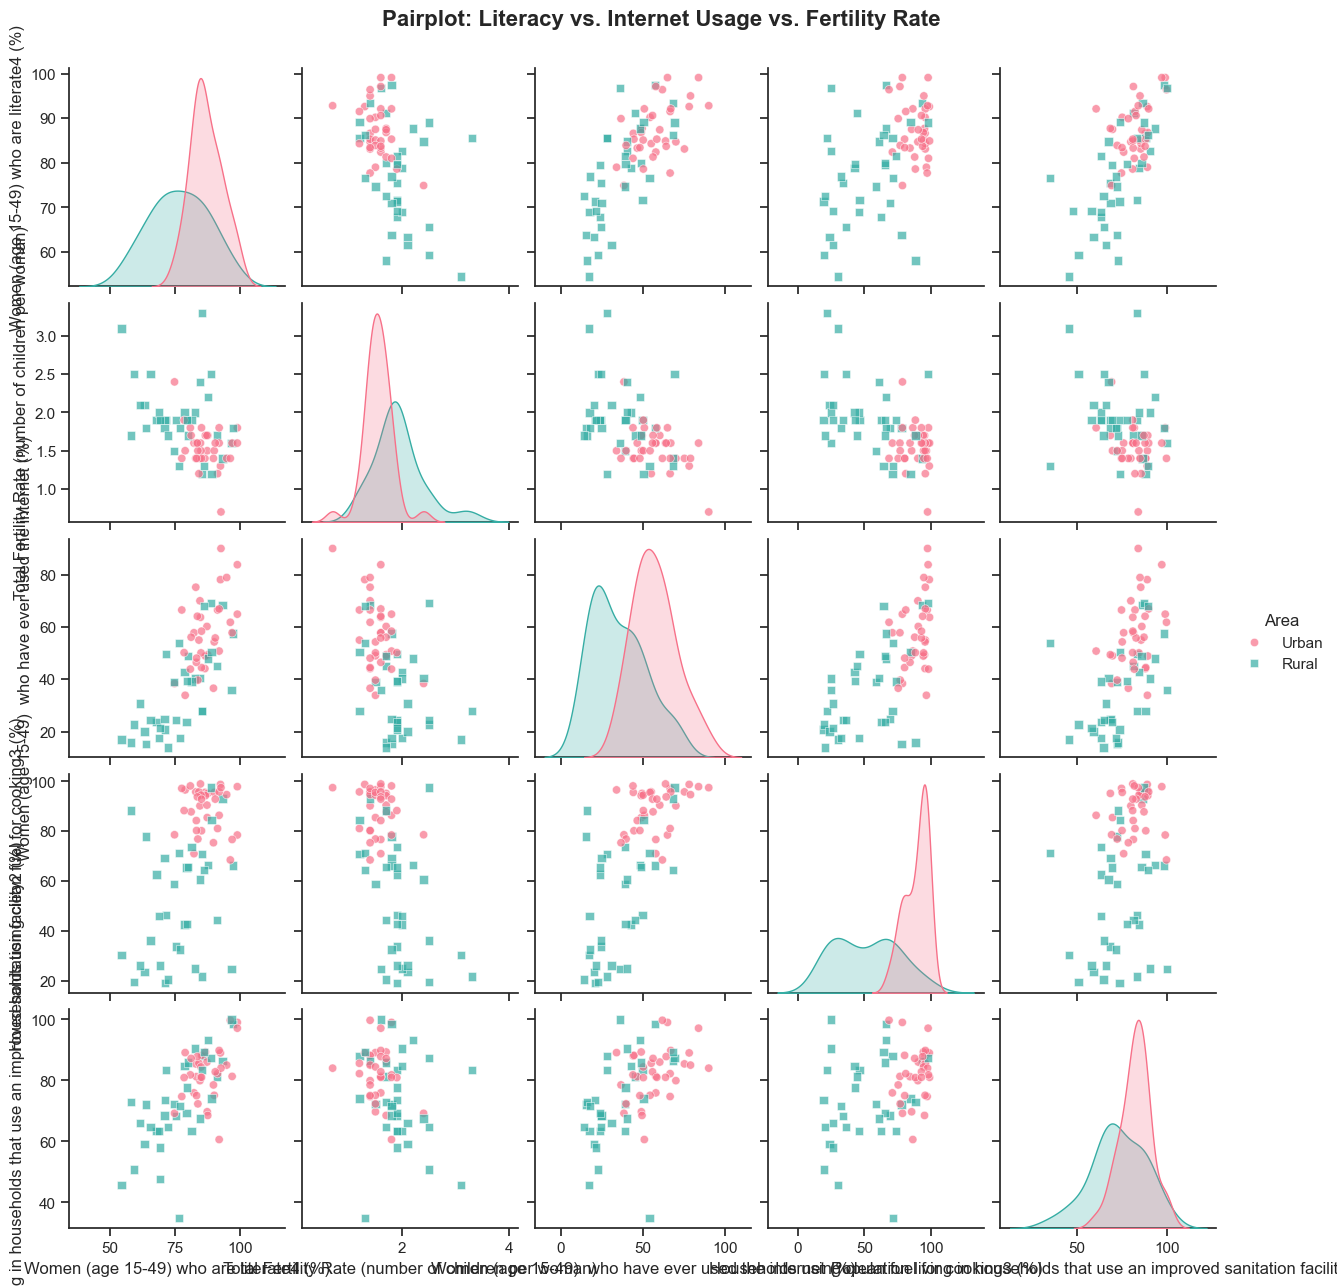

In [23]:
pairplot_df = df[(df['States/UTs'] != 'India') & (df['Area'].isin(['Urban', 'Rural']))].copy()


sns.set_theme(style="ticks")

g = sns.pairplot(
    pairplot_df[cols + ['Area']], 
    hue='Area',              
    palette='husl',          
    diag_kind='kde',         
    markers=["o", "s"],      
    plot_kws={'alpha': 0.7}  
)
g.fig.suptitle('Pairplot: Literacy vs. Internet Usage vs. Fertility Rate', y=1.03, fontsize=16, fontweight='bold')

plt.show()

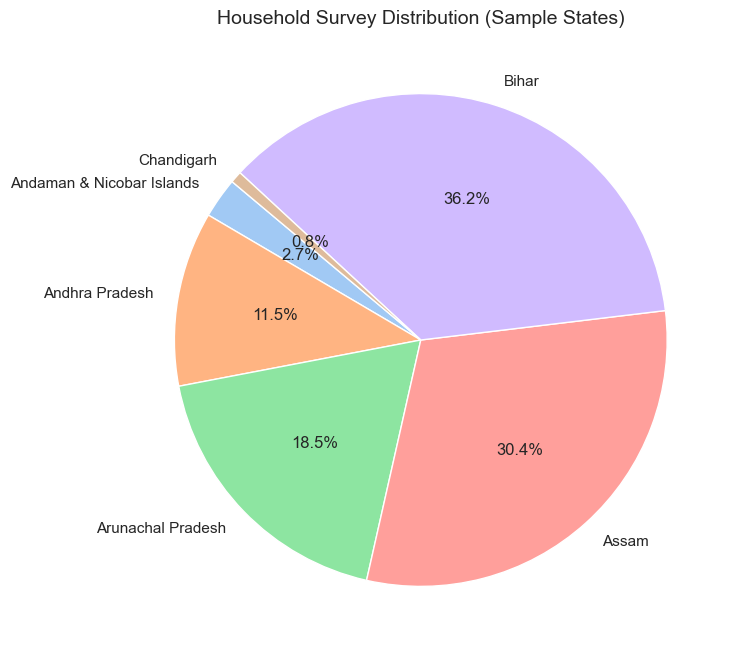

In [24]:
pie_data = df[(df['Area'] == 'Total') & (df['States/UTs'] != 'India')].head(6) 
plt.figure(figsize=(8, 8))
plt.pie(pie_data['Number of Households surveyed'], labels=pie_data['States/UTs'], autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Household Survey Distribution (Sample States)', fontsize=14)
plt.show()

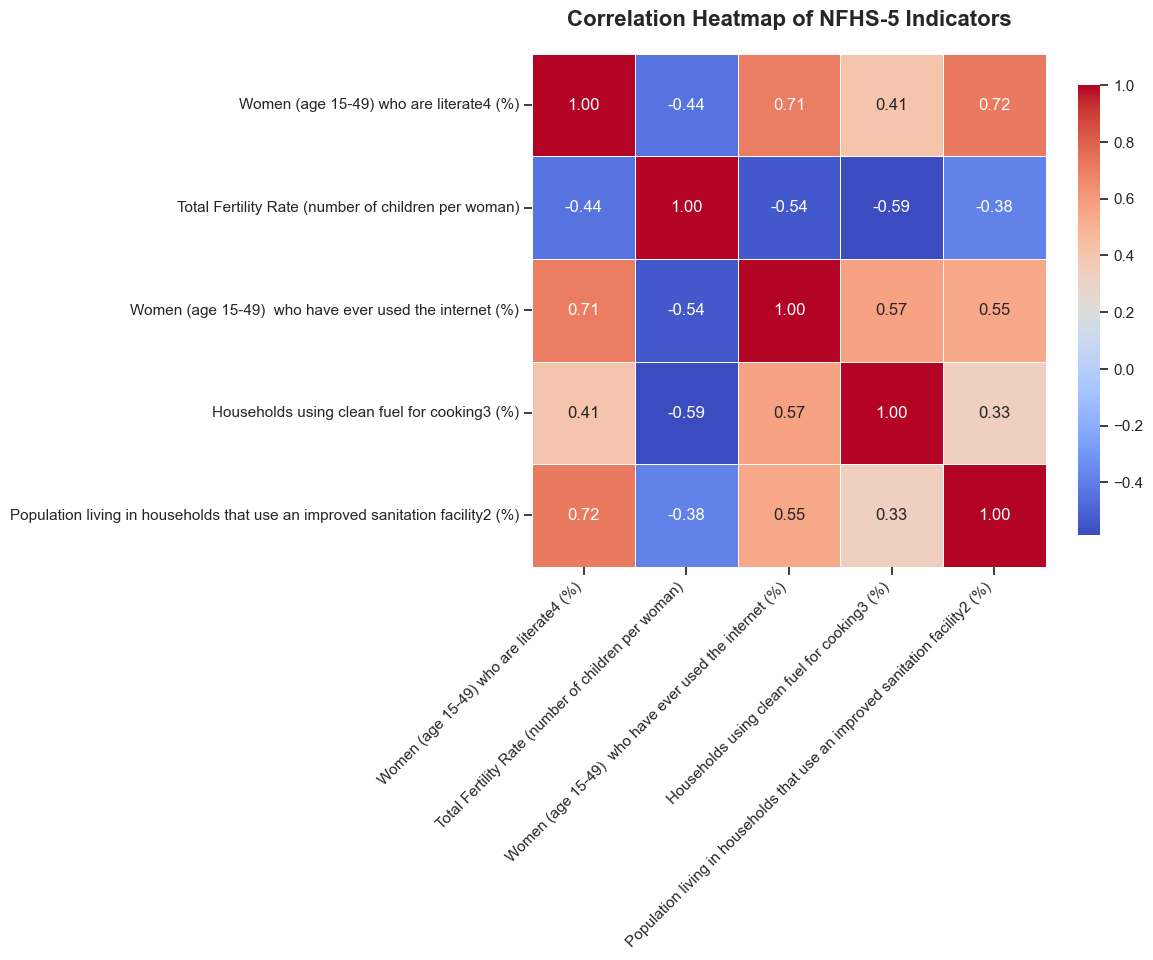

In [26]:
corr_matrix = df[(df['Area'] == 'Total') & (df['States/UTs'] != 'India')][cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',     
    linewidths=0.5,      
    square=True,         
    cbar_kws={"shrink": .8} 
)

plt.title('Correlation Heatmap of NFHS-5 Indicators', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Samples available for modelling: 35
       Women (age 15-49) who are literate4 (%)  \
count                                    35.00   
mean                                     80.27   
std                                       9.80   
min                                      57.80   
25%                                      74.20   
50%                                      81.40   
75%                                      86.80   
max                                      98.30   

       Women (age 15-49)  who have ever used the internet (%)  \
count                                              35.00        
mean                                               43.86        
std                                                16.29        
min                                                20.60        
25%                                                30.70        
50%                                                43.30        
75%                                                55.60  

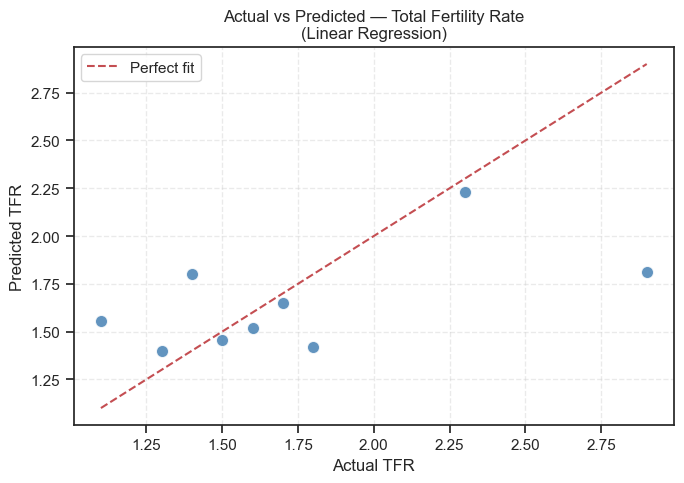

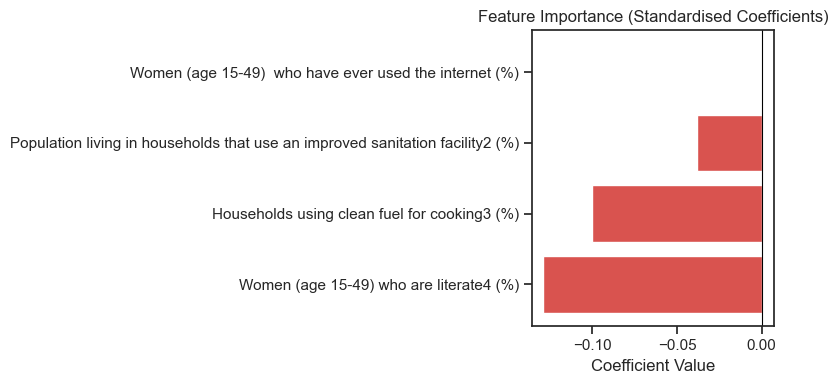

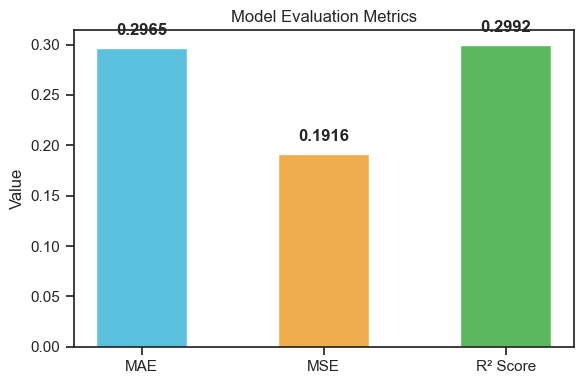

In [28]:
df_ml = pd.read_csv('cleaned_data.csv')

def clean_data(val):
    if pd.isna(val) or val == "" or val == " ":
        return np.nan
    val = str(val).strip().replace("(", "").replace(")", "")
    try:
        return float(val)
    except ValueError:
        return np.nan

feature_cols = [
    'Women (age 15-49) who are literate4 (%)',
    'Women (age 15-49)  who have ever used the internet (%)',
    'Households using clean fuel for cooking3 (%)',
    'Population living in households that use an improved sanitation facility2 (%)'
]
target_col = 'Total Fertility Rate (number of children per woman)'

all_cols = feature_cols + [target_col]
for col in all_cols:
    df_ml[col] = df_ml[col].apply(clean_data)


df_ml = (df_ml[df_ml['Area'] == 'Total']
           .query("`States/UTs` != 'India'")
           [all_cols]
           .dropna())

print(f"Samples available for modelling: {len(df_ml)}")
print(df_ml.describe().round(2))


X = df_ml[feature_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train_sc, y_train)


y_pred = model.predict(X_test_sc)


mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n" + "="*45)
print("       MODEL EVALUATION METRICS")
print("="*45)
print(f"  Mean Absolute Error  (MAE) : {mae:.4f}")
print(f"  Mean Squared Error   (MSE) : {mse:.4f}")
print(f"  R² Score             (R²)  : {r2:.4f}")
print("="*45)


coeff_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

print("\nFeature Coefficients (scaled):")
print(coeff_df.to_string(index=False))


plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='white', s=80, alpha=0.85)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual TFR')
plt.ylabel('Predicted TFR')
plt.title('Actual vs Predicted — Total Fertility Rate\n(Linear Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


plt.figure(figsize=(8, 4))
colors = ['#d9534f' if c < 0 else '#5cb85c' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Standardised Coefficients)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))
metrics = ['MAE', 'MSE', 'R² Score']
values  = [mae, mse, r2]
bar_colors = ['#5bc0de', '#f0ad4e', '#5cb85c']
bars = ax.bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Model Evaluation Metrics')
ax.set_ylabel('Value')
plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150)
plt.show()
